<a href="https://colab.research.google.com/github/hend-22/-IT326-Project/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/hend-22/-IT326-Project/main/Dataset/Raw_Dataset.csv"
df = pd.read_csv(url)

df.shape

(10000, 16)

#**Five-Number Summary**

####The five-number summary is used to describe the distribution of the numerical attributes using the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values.

In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]


,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
min,18.0,17.5,0.0,0.5,2.0,1000.00,491.0,50.0,3.5,0.7,1.0
25%,31.0,22.3,100.0,2.0,5.3,4919.50,1354.0,61.0,6.3,1.4,3.5
50%,43.0,25.1,201.0,2.5,7.1,7396.50,1561.0,67.0,7.0,1.7,4.2
75%,56.0,27.8,303.0,3.0,8.7,10119.25,1786.0,73.0,7.6,2.1,4.8
max,69.0,38.0,730.0,5.0,14.0,23451.00,2901.0,95.0,10.9,3.4,7.5


#**Statistical Summary**

####The statistical summary provides descriptive statistics for the numerical attributes, including count, mean, standard deviation, minimum, quartiles, and maximum values.

In [ ]:
df.describe()

,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
count,10000.000000,9790.000000,9794.000000,10000.000000,10000.000000,10000.000000,10000.000000,9781.000000,9810.000000,10000.000000,10000.000000
mean,43.539400,25.087406,207.365224,2.502550,7.060990,7963.857000,1573.986300,66.944177,6.957951,1.750610,4.170080
std,14.911636,3.905276,137.681368,0.802058,2.443689,4021.490815,320.153851,8.450527,0.907726,0.467773,0.914011
min,18.000000,17.500000,0.000000,0.500000,2.000000,1000.000000,491.000000,50.000000,3.500000,0.700000,1.000000
25%,31.000000,22.300000,100.000000,2.000000,5.300000,4919.500000,1354.000000,61.000000,6.300000,1.400000,3.500000
50%,43.000000,25.100000,201.000000,2.500000,7.100000,7396.500000,1561.000000,67.000000,7.000000,1.700000,4.200000
75%,56.000000,27.800000,303.000000,3.000000,8.700000,10119.250000,1786.000000,73.000000,7.600000,2.100000,4.800000
max,69.000000,38.000000,730.000000,5.000000,14.000000,23451.000000,2901.000000,95.000000,10.900000,3.400000,7.500000


#**Outliers Detection**

####Outliers are detected using the Interquartile Range (IQR) method. Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered outliers.

In [ ]:
# Select numerical attributes
numeric_columns = df.select_dtypes(include='number').columns

# Detect outliers using the IQR method
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(column, ":", len(outliers), "outliers")

Age : 0 outliers
BMI : 25 outliers
Caffeine_Intake_mg : 25 outliers
Water_Intake_liters : 47 outliers
Screen_Time_Hours : 38 outliers
Daily_Steps : 182 outliers
Calories_Burned : 59 outliers
Resting_Heart_Rate : 7 outliers
Daily_Sleep_Hours : 43 outliers
Deep_Sleep_Hours : 9 outliers
Sleep_Quality_Score : 43 outliers


#**Boxplots**

####Boxplots are used to visualize the distribution of the numerical attributes and identify potential outliers.

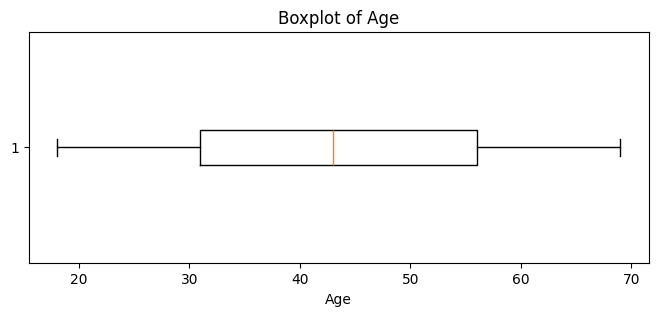

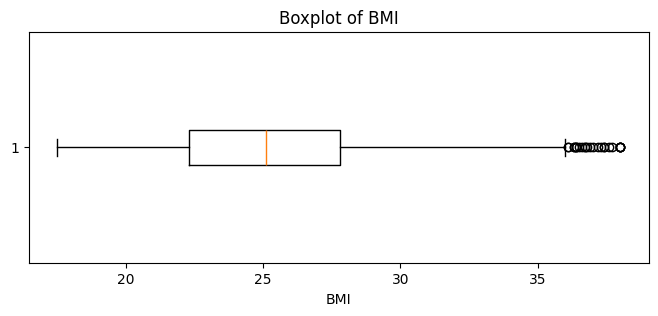

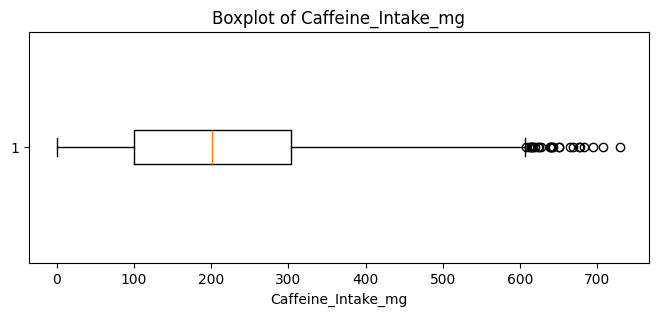

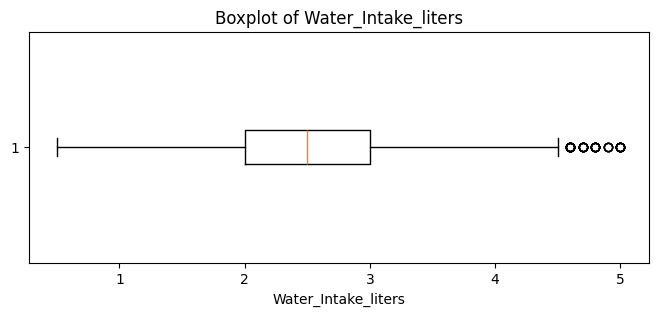

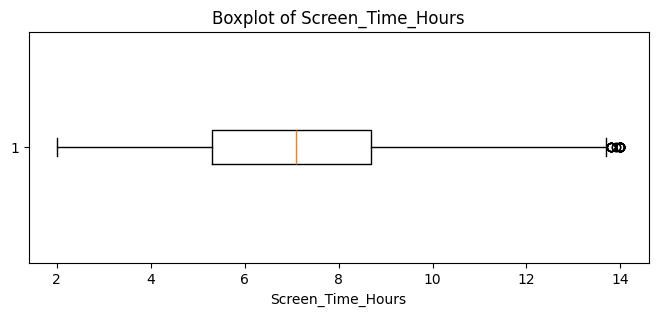

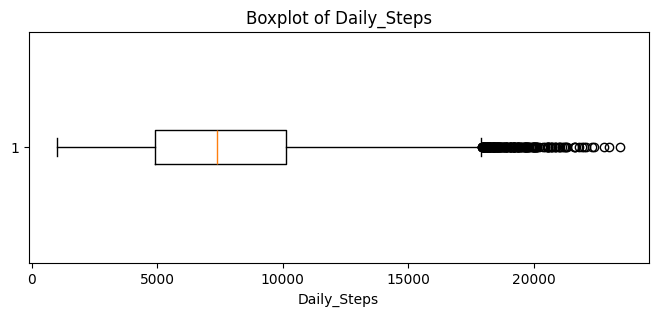

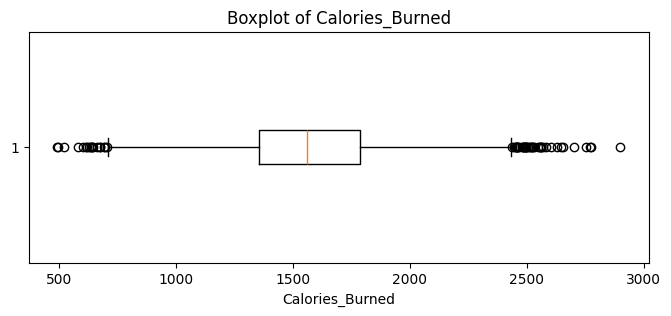

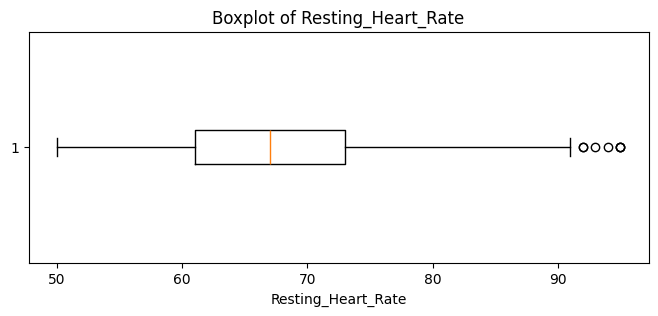

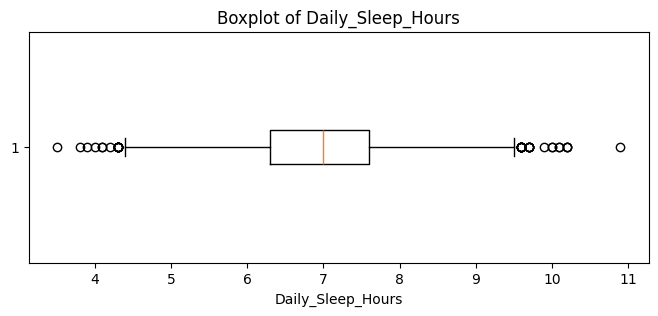

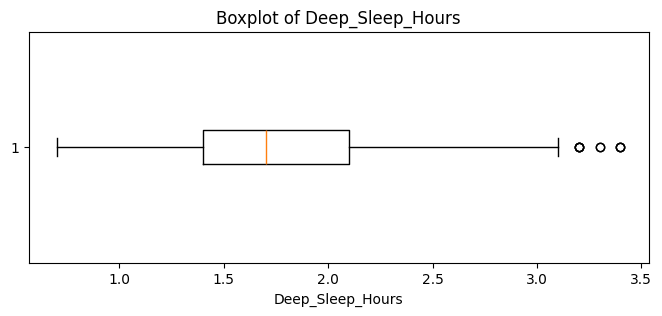

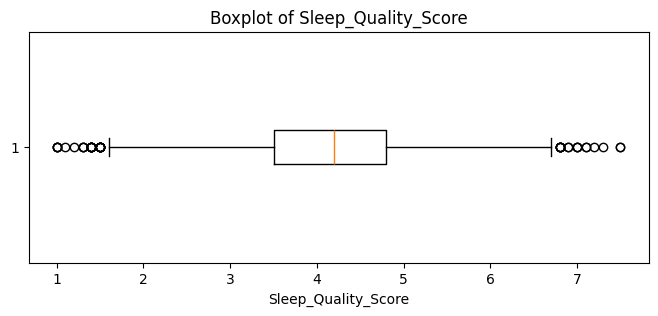

In [ ]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

#**Boxplot Analysis**

####The boxplots show that most numerical attributes contain outliers, while Age has no detected outliers. Daily_Steps has the highest number of outliers, with 182 values identified using the IQR method. Other attributes, such as BMI, Caffeine_Intake_mg, Water_Intake_liters, Screen_Time_Hours, Calories_Burned, Resting_Heart_Rate, Daily_Sleep_Hours, Deep_Sleep_Hours, and Sleep_Quality_Score also contain outliers. These results indicate that the outliers should be considered during the preprocessing stage before applying the data mining techniques.

##Histograms and Variable Distributions


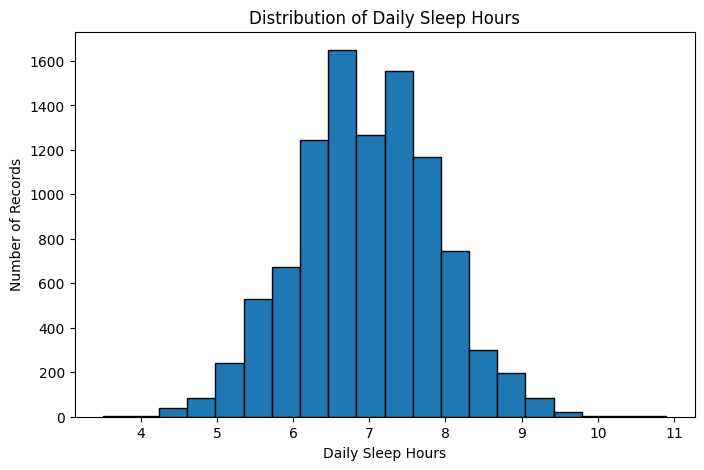

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Daily_Sleep_Hours'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Daily Sleep Hours')
plt.xlabel('Daily Sleep Hours')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:**  Most daily sleep-hour values are concentrated between approximately 6 and 8 hours. Fewer records appear at very low or high sleep durations. The distribution should be considered when checking unusual values during preprocessing.

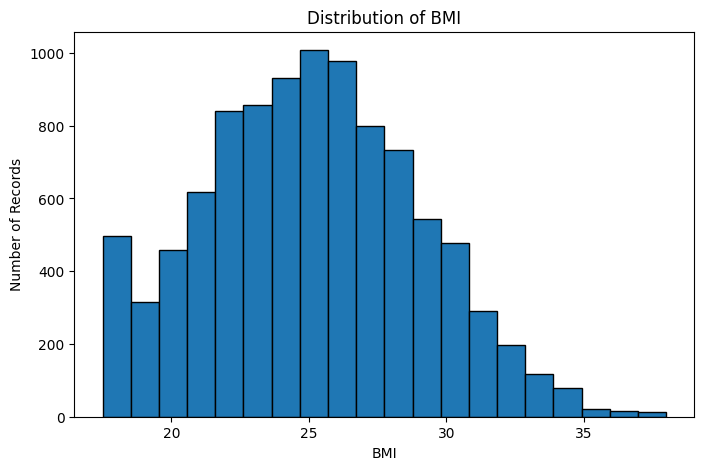

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['BMI'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most BMI values are concentrated between approximately 22 and 28, with a peak near 25. Higher BMI values are less frequent and form a tail on the right. These values should be checked during preprocessing before deciding whether they need any treatment.


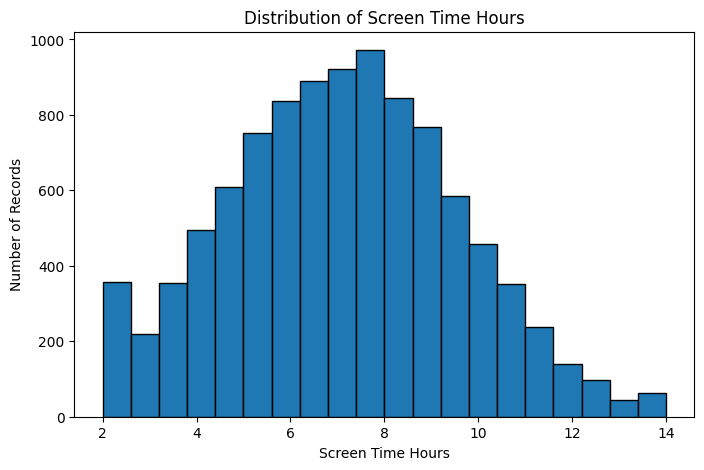

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Screen_Time_Hours'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Screen Time Hours')
plt.xlabel('Screen Time Hours')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most screen-time values are concentrated between approximately 5 and 10 hours, with the highest frequency around 7–8 hours. Very low and very high screen-time values are less common. Values at the ends of the distribution should be reviewed during preprocessing before deciding whether any treatment is needed.

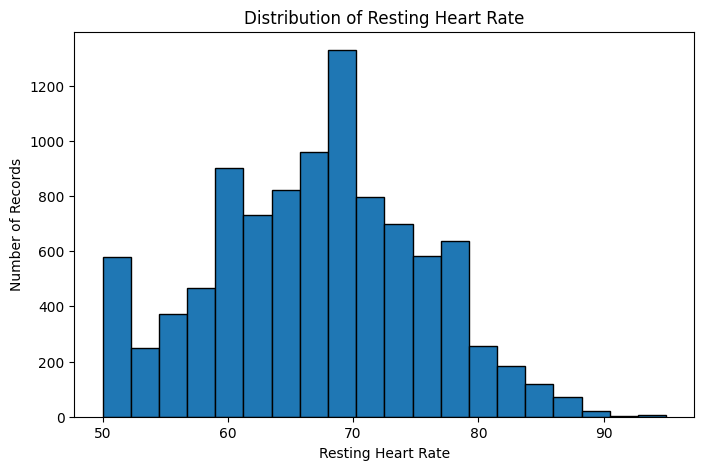

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Resting_Heart_Rate'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Resting Heart Rate')
plt.xlabel('Resting Heart Rate')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most resting heart rate values are concentrated between approximately 58 and 78, with the highest frequency around 68–70. Values above 85 are less common. These high values should be reviewed during preprocessing before deciding whether they require treatment.

# **Scatter Plot**

A scatter plot shows the relationship between two variables. Each point represents one person, helping us see whether changes in one variable are linked to changes in another.

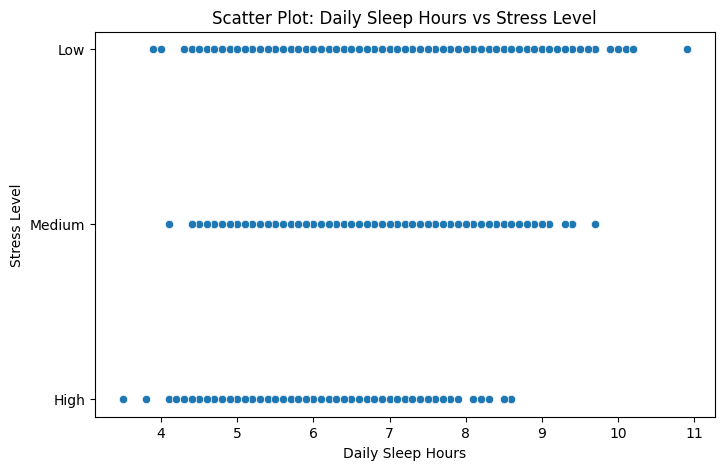

In [ ]:

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Daily_Sleep_Hours'], y=df['Daily_Stress_Level'])
plt.title('Scatter Plot: Daily Sleep Hours vs Stress Level')
plt.ylabel('Stress Level')
plt.show()

**Interpretation:** The plot shows that stress levels (Low, Medium, High) are spread across different sleep durations without a clear pattern. Individuals with 6–8 hours of sleep appear in all stress categories. There is no visible trend indicating that sleeping more or less strongly affects stress levels.

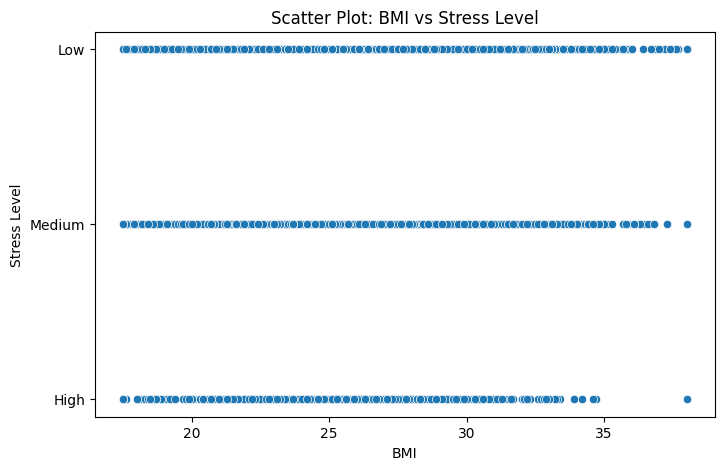

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['BMI'], y=df['Daily_Stress_Level'])
plt.title('Scatter Plot: BMI vs Stress Level')
plt.xlabel('BMI')
plt.ylabel('Stress Level')
plt.show()

**Interpretation:** Stress levels are distributed evenly across various BMI values. Low, Medium, and High stress categories appear at both low and high BMI ranges. This suggests that BMI does not show a strong or consistent relationship with stress level in this dataset.

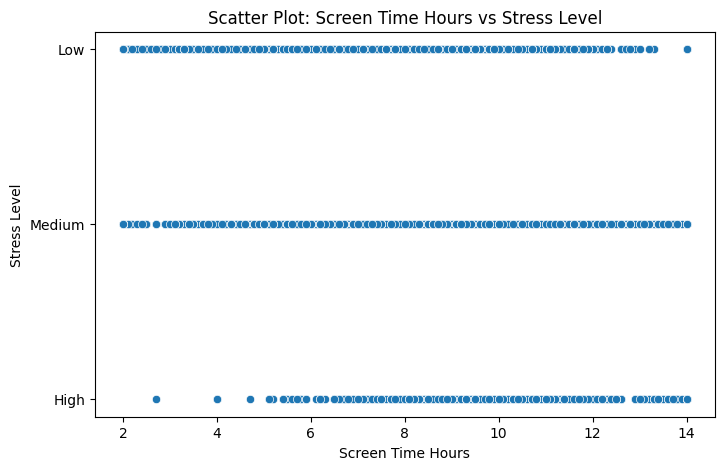

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Screen_Time_Hours'], y=df['Daily_Stress_Level'])
plt.title('Scatter Plot: Screen Time Hours vs Stress Level')
plt.xlabel('Screen Time Hours')
plt.ylabel('Stress Level')
plt.show()

**Interpretation:** The points are spread across all stress levels for different screen time durations. Most individuals fall under Low and Medium stress regardless of screen time. This indicates a weak or unclear relationship between screen time and stress level.

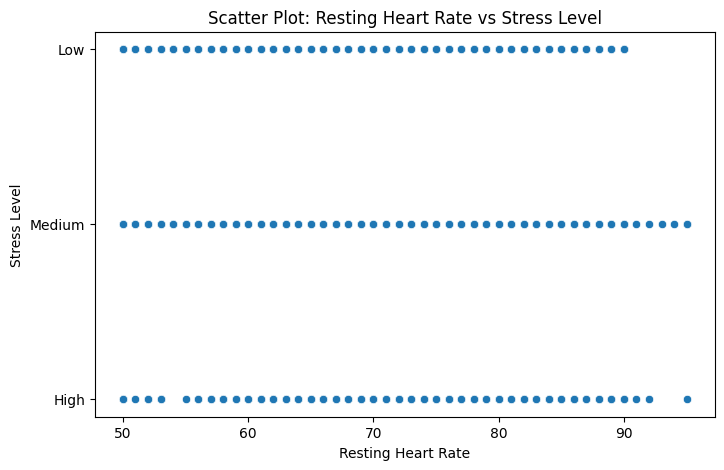

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Resting_Heart_Rate'], y=df['Daily_Stress_Level'])
plt.title('Scatter Plot: Resting Heart Rate vs Stress Level')
plt.xlabel('Resting Heart Rate')
plt.ylabel('Stress Level')
plt.show()

**Interpretation:** Stress levels appear across all heart rate values without a noticeable pattern. Low and Medium stress levels are common at both low and high resting heart rates. High stress is rare. This suggests that resting heart rate does not strongly predict stress level in this dataset.

# **Bar Plot**

A bar plot compares the average value of a variable across different categories. It helps us see differences or similarities between groups.

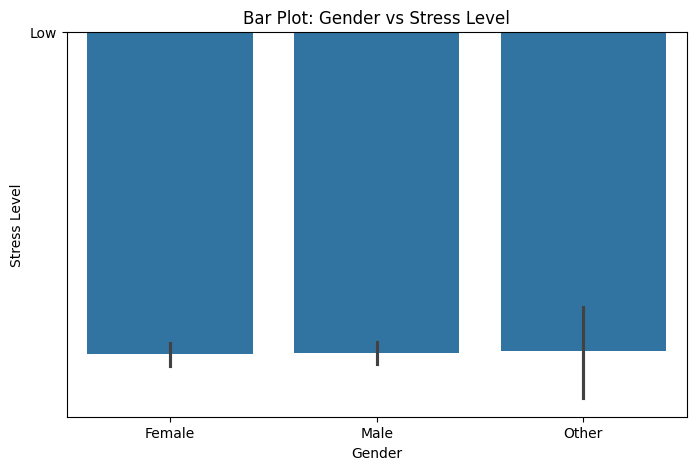

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Gender'], y=df['Daily_Stress_Level'])
plt.title('Bar Plot: Gender vs Stress Level')
plt.xlabel('Gender')
plt.ylabel('Avrege Stress Level')
plt.show()

**Interpretation:** The average stress level is nearly the same across all gender categories (Female, Male, Other). This indicates that gender does not have a significant impact on stress level in this dataset.

# **Countplot**

A countplot shows how many observations fall into each category. It is useful for checking whether the dataset is balanced or imbalanced.

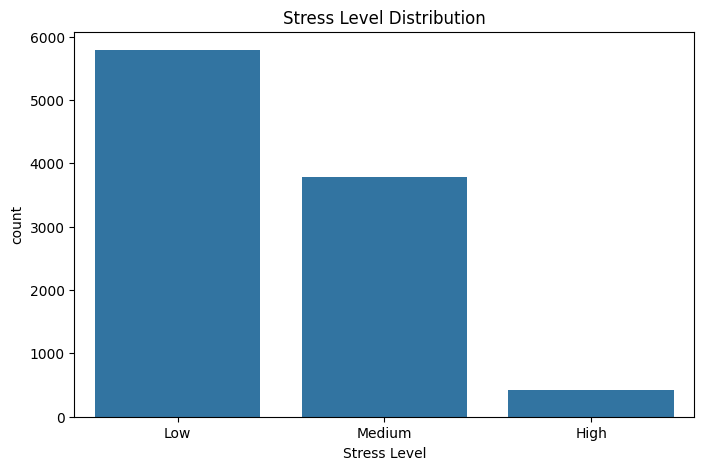

,count
Daily_Stress_Level,
Low,5789
Medium,3786
High,425


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Daily_Stress_Level'])
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()
df['Daily_Stress_Level'].value_counts()

**Interpretation:** Low stress is the most common category, followed by Medium. High stress is very rare. This imbalance shows that the dataset is dominated by lower stress levels, which may influence analysis and model performance.